#### Modellərin keyfiyyətinin Ehtimal əsaslı qiymətləndirilməsi - Probabilistic Evaluation of model quality

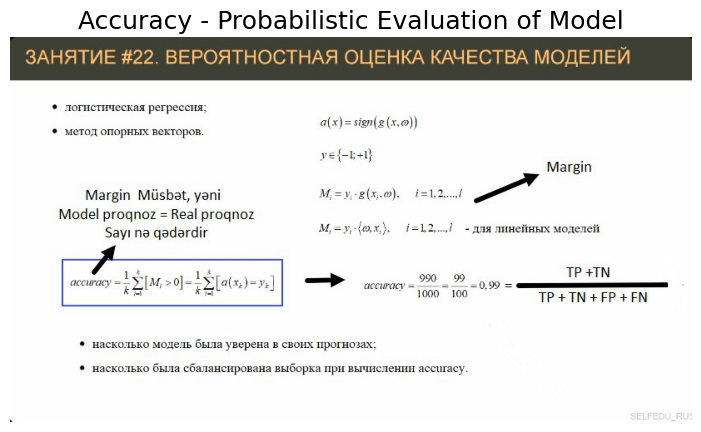

In [4]:
from PIL import Image

# Fayl yolunun əsas hissəsi
base_path = r'C:\Users\dell\Desktop\Selfedu\Pictures\ML_22_'

# Şəkilləri saxlayacağımız siyahı
image_list = []

# 1-dən 5-ə qədər olan şəkilləri dövr ilə açırıq
for i in range(1, 2):  # 1-dən 5-ə qədər
    full_path = f'{base_path}{i}.jpg'  # Fayl yolunu dinamik olaraq yaradırıq
    img = Image.open(full_path)
    image_list.append(img)  # Şəkili siyahıya əlavə edirik

# Nəticə: images siyahısında bütün yüklənmiş şəkillər olacaq

import matplotlib.pyplot as plt

# Şəkilləri göstərin
for i, image in enumerate(image_list):
    if i == 100:
        plt.figure(figsize=(8.8, 4))          
    else:     
        plt.figure(figsize=(25, 5))  # Şəkilin ölçüsü    
        
    if i < 100:
        plt.title("""Accuracy - Probabilistic Evaluation of Model""", size='18')   
    
    plt.imshow(image)
    plt.axis('off')  # Oxları gizlətmək üçün
    plt.show()

### Margin-in ($\cdot y$-siz) mənası

> **Margin ($\cdot y$-siz) — Bir nöqtənin iki sinfi ayıran xətdən nə qədər uzaqda olduğunu və xəttin hansı tərəfində yerləşdiyini göstərir. Yəni $w^T x + b$  təkcə tərəfi yox, həm də uzaqlıqla bağlı məlumat verir, amma tam uzaqlıq deyil. Hələki  $y$-ə çarpmadığımıza görə bilmirk Model düz qərar verib ya yox**

<br>

#### 🔹 **1. Nəyi göstərir?**

> **İşarə → hansı tərəfdədir**

> **Modul (böyüklük) → xəttdən nə qədər uzaqdır (amma scaled şəkildə)**

<br>

#### 🔹 **2. Amma bu real məsafə deyil ❗**

Çünki $w$-nin ölçüsündən asılıdır.

👉 Həqiqi (perpendicular) məsafə belədir:

$d = \frac{|w^T x + b|}{|w|}$

<br>

#### 🔹 **3. Intuitiv izah:**

* $w^T x + b$ → “uzaqlıq + istiqamət (scale olunmuş)”
* $||w||$-ə böləndə → **real məsafə alınır**

<br>

#### **🔚 Qısa yekun:**

- ✔ $w^T x + b$ → **tərəf + uzaqlıq (amma dəqiq yox)**
- ✔ $\frac{|w^T x + b|}{||w||}$ → **real məsafə**
- $∥w∥$-ə **ona görə bölürük ki, çünki məsafə = proyeksiya / normal vektorun uzunluğu. $w$ nə qədər böyükdürsə, $w^T x + b$ da süni böyüyür → buna görə normaya bölüb normallaşdırırıq.**
- 👉 $||w||$ **isə minimallaşdırılır ki, Margin (yəni xəttdən minimum məsafə) maksimum olsun**.

 <br>

#### 🔹 **Qərar xətti:**

$$
w^T x + b = 0
$$

<br>

#### 🔹 **İndi baxaq:**

* **$w^T x + b > 0$**
  → nöqtə xəttin **bir tərəfindədir**

* **$w^T x + b < 0$**
  → nöqtə xəttin **digər tərəfindədir**

<br>

#### 🔹 **Vacib nüans:**

Bu “hansı tərəf” olduğu **işarədən asılıdır**, amma:

* hansı tərəfin “+” və ya “−” olması → $w$ vektorunun istiqamətindən asılıdır

<br>

#### 🔹 **Intuitiv:**

- $w^T x + b$ sadəcə deyir:
-  👉 “sən xəttin hansı tərəfindəsən?”

<br>

#### **🔚 Yekun:**

- ✔ Müsbət → bir tərəf
- ✔ Mənfi → digər tərəf
- ✔ 0 → düz xəttin üstü


### Margin-in ($\cdot y$ ilə) mənası

> **Margin ($\cdot y$ ilə) — Modelin bir nöqtəni düzgün düzgün təsnif edib-etmədiyini və iki sinfi ayıran xətdən nə qədər uzaqda olduğunu göstərir. Yəni $ y(w^T x + b) $ düzgünlük məlumatını verir, böyüklüyü isə uzaqlıqla bağlıdır (amma hələ tam məsafə deyil). $y$-ə vurduğumuza görə artıq bilirik ki model düz qərar verib ya yox.**

<br>

#### 🔹 **Məntiq:**

**Tam olaraq söhbət bir nöqtədən gedir** 👍

> **Yəni biz hər dəfə bir data point, yəni bir nümunə - Özü ve Class-ı (bir ($x_i, y_i)$) götürürük və baxırıq:**

$$
y_i (w^T x_i + b)
$$

<br>

#### Model deyir:
$$
w^T x + b
$$
→ modelin **proqnozu (işarəsi)**

<br>

#### Real cavab:
$$
y
$$
→ **həqiqi label** ($**+1$** və ya $**-1$**)

<br>

#### ✅ **1. Model müsbət dedi, real da müsbətdir**

- $ w^T x + b > 0 $
- $ y = +1 $
-  → $ y(w^T x + b) > 0 $ → **doğru**

<br>

#### ❌ **2. Model müsbət dedi, real mənfidir**

- $ w^T x + b > 0 $
- $ y = -1 $
- → $ y(w^T x + b) < 0 $ → **səhv**

<br>

#### ❌ **3. Model mənfi dedi, real müsbətdir**

- $ w^T x + b < 0 $
- $ y = +1 $
- → $ y(w^T x + b) < 0 $ → **səhv**

<br>

#### ✅ **4. Model mənfi dedi, real da mənfidir**

- $ w^T x + b < 0 $
- $ y = -1 $
- → $ y(w^T x + b) > 0 $ → **doğru**

<br>

#### ⚠️ **5. Sərhəd halı (decision boundary)**

- $ w^T x + b = 0 $
-  → $ y(w^T x + b) = 0 $
-  → model **tam qərarsızdır** (sərhəddədir)

<br>

#### **🔚 Bir cümlə (tam versiya):**

> **Modelin dediyi işarə ilə real $y$-nin işarəsi eynidirsə → vuranda müsbət çıxır (doğru), fərqlidirsə → mənfi çıxır (səhv), $0$ olarsa → nöqtə sərhəddədir.**


### Accuracy 

> **Accuracy (dəqiqlik)** — **modelin düzgün təsnif etdiyi nümunələrin bütün nümunələrə nisbətidir. Yəni, modelin nə qədər “doğru” işlədiyini göstərir.**

<br>

#### **Diqqqət ediləsi nüans**
> **Qısa desək, accuracy modelin ümumi düzgünlüyünü ölçür, amma Balanssız (məsələn, 95% mənfi, 5% müsbət olan) datasetlərdə yanıltıcı ola bilər.**

> **Accuracy (dəqiqlik) maşın öyrənməsi və statistika sahəsində ən sadə performans ölçülərindən biridir. O, modelin düzgün proqnoz verdiyi halların ümumi hallara nisbətini göstərir.**

**Tərifi:**

$$
\text{Accuracy} = \frac{\text{Düzgün təsnif olunan nümunələrin sayı}}{\text{Ümumi nümunələrin sayı}}
$$

<br>

**Confuison Matrix**


|                   | **Model Positive**           | **Model Negative**            |
| ----------------- | ---------------------------- | ----------------------------- |
| **Real Positive** | <div style="text-align:center">**TP**                       | <div style="text-align:center">**FN** <br> **Type II Error** |
| **Real Negative** |  <div style="text-align:center">**FP** <br> **Type I Error** | <div style="text-align:center">**TN**                        |

<br>
    
**Simvolik düsturla:**

$$
\text{Accuracy} = \frac{TP + TN}{TP + TN + FP + FN}
$$

Burada:

* $TP$ = True Positive (doğru müsbət)
* $TN$ = True Negative (doğru mənfi)
* $FP$ = False Positive (səhv müsbət)
* $FN$ = False Negative (səhv mənfi)


**Misal:**
100 nümunədən 90-ını düzgün proqnoz etsək, accuracy belə hesablanır:
$$
\text{Accuracy} = \frac{90}{100} = 0.9 = 90%
$$


Qısa desək: **Accuracy = Düzgünlərin faizi**.
